In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

In [2]:
import pandas as pd

# Try different encodings, such as 'latin-1' or 'iso-8859-1'
df = pd.read_csv("/content/spam.csv", encoding='latin-1')
# if 'latin-1' doesn't work, try 'iso-8859-1' or others

df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.groupby('v1').describe()

v2                                                                 \
     count unique                                                top freq   
v1                                                                          
ham   4825   4516                             Sorry, I'll call later   30   
spam   747    653  Please call our customer service representativ...    4   

     Unnamed: 2                                                            \
          count unique                                                top   
v1                                                                          
ham          45     39   bt not his girlfrnd... G o o d n i g h t . . .@"   
spam          5      4                                        PO Box 5249   

          Unnamed: 3                                    Unnamed: 4         \
     freq      count unique                    top freq      count unique   
v1                                                                          
ham     3         10      9                     GE    2          6      5   
spam    2          2      1   MK17 92H. 450Ppw 16"    2          0      0   

                    
          top freq  
v1                  
ham   GNT:-)"    2  
spam      NaN  NaN

In [4]:
df_spam = df[df['v1']=='spam']
df_ham = df[df['v1']=='ham']
print('Number of spam messages: ', df_spam.shape[0])
print('Number of ham messages: ', df_ham.shape[0])

Number of spam messages:  747
Number of ham messages:  4825


In [5]:
df_ham_downsampled = df_ham.sample(df_spam.shape[0])
df_ham_downsampled.shape

# The sample method is used to randomly select a subset of rows from the df_ham DataFrame.

(747, 5)

In [6]:
df_balanced = pd.concat([df_spam,df_ham_downsampled])
df_balanced.shape

(1494, 5)

In [7]:
df_balanced['v1'].value_counts()

,count
v1,
spam,747
ham,747


In [8]:
df_balanced['spam'] = df_balanced['v1'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

#  this line is converting the text labels in the v1 column ('spam' or 'ham') into numerical labels
#  in the new spam column (1 for 'spam' and 0 for 'ham').

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,spam
2655,ham,Great! I have to run now so ttyl!,NaN,NaN,NaN,0
5205,spam,Had your mobile 11mths ? Update for FREE to Or...,NaN,NaN,NaN,1
3139,spam,sexy sexy cum and text me im wet and warm and ...,NaN,NaN,NaN,1
1690,spam,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...,NaN,NaN,NaN,1
3338,ham,Babe !!!! I LOVE YOU !!!! *covers your face in...,NaN,NaN,NaN,0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['v2'], df_balanced['spam'], stratify=df_balanced['spam'])

In [10]:
X_train.head(4)

,v2
3533,Good evening! How are you?
747,U are subscribed to the best Mobile Content Se...
1897,"Aight, sounds good. When do you want me to com..."
4744,Camera - You are awarded a SiPix Digital Camer...


Import pretrained modles from tensorflow

In [11]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
# This model handles tasks like tokenization (splitting text into words or subwords) and
# converting words into numerical representations that BERT can understand

bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")
# L-12: indicates it has 12 encoder layers.
# H-768: signifies a hidden size of 768.
# A-12: denotes 12 attention heads.
# This model is responsible for generating contextualized word embeddings – numerical
# representations of words that capture their meaning within the sentence.

In [13]:
def get_sentence_embeding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']

# The pooled output provides a fixed-length vector representation for the entire input sequence


get_sentence_embeding([
    "500$ discount, hurry up",
    "Bhavin, are you up for a volleybal game tomorrow?"
])

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.77342033, -0.5013773 , -0.8073749 , ..., -0.605766  ,
        -0.7409631 ,  0.8849831 ],
       [-0.8720835 , -0.50543964, -0.9444668 , ..., -0.8584751 ,
        -0.7174534 ,  0.88082975]], dtype=float32)>

In [14]:
e = get_sentence_embeding([
    "banana",
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
])

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])

# it will compare two metrics so here it is comparing banana and grapes

array([[0.9911088]], dtype=float32)

In [18]:
cosine_similarity([e[3]],[e[4]])

array([[0.9872036]], dtype=float32)

In [19]:
#Bert layers

text_input = tf.keras.layers.Input(shape=(),dtype=tf.string,name="text")
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

#Neural network layers

l = tf.keras.layers.Dropout(0.1,name="dropout")(outputs['pooled_output'])
l = tf.keras.layers.Dense(1,activation='sigmoid',name="output")(l)

# here only 1 dense layer as it will suggest email is spam or not and therefore sigmoid activation function
# is used for binary classification task

#Construct final model
model = tf.keras.Model(inputs=[text_input],outputs=[l])

In [20]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

In [21]:
METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [22]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
35/35 [==============================] - 487s 14s/step - loss: 0.6573 - accuracy: 0.5973 - precision: 0.5910 - recall: 0.6321
Epoch 2/10
35/35 [==============================] - 462s 13s/step - loss: 0.5304 - accuracy: 0.7875 - precision: 0.7949 - recall: 0.7750
Epoch 3/10
35/35 [==============================] - 462s 13s/step - loss: 0.4518 - accuracy: 0.8491 - precision: 0.8353 - recall: 0.8696
Epoch 4/10
35/35 [==============================] - 463s 13s/step - loss: 0.4055 - accuracy: 0.8687 - precision: 0.8629 - recall: 0.8768
Epoch 5/10
35/35 [==============================] - 462s 13s/step - loss: 0.3746 - accuracy: 0.8696 - precision: 0.8569 - recall: 0.8875
Epoch 6/10
35/35 [==============================] - 466s 13s/step - loss: 0.3500 - accuracy: 0.8929 - precision: 0.8806 - recall: 0.9089
Epoch 7/10
35/35 [==============================] - 464s 13s/step - loss: 0.3281 - accuracy: 0.8911 - precision: 0.8815 - recall: 0.9036
Epoch 8/10
35/35 [=======================

In [23]:
model.evaluate(X_test,y_test)

12/12 [==============================] - 154s 13s/step - loss: 0.2666 - accuracy: 0.9251 - precision: 0.9077 - recall: 0.9465


[0.2665623426437378,
 0.9251337051391602,
 0.9076923131942749,
 0.9465240836143494]

In [24]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

12/12 [==============================] - 155s 13s/step


In [25]:
import numpy as np
y_predicted = np.where(y_predicted > 0.5,1,0)
y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [26]:
from matplotlib import pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(y_test,y_predicted)
cm

array([[169,  18],
       [ 10, 177]])

Text(50.722222222222214, 0.5, 'Truth')

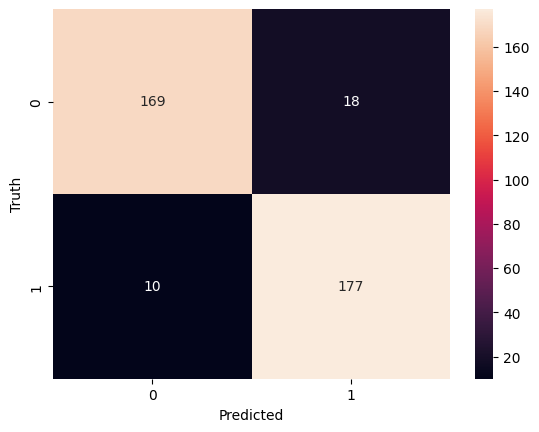

In [27]:
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [28]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       187
           1       0.91      0.95      0.93       187

    accuracy                           0.93       374
   macro avg       0.93      0.93      0.93       374
weighted avg       0.93      0.93      0.93       374



In [29]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]

model.predict(reviews)

1/1 [==============================] - 4s 4s/step


array([[0.7917697 ],
       [0.85364264],
       [0.814216  ],
       [0.2241213 ],
       [0.09483986]], dtype=float32)